In [2]:
import sys
import os
import numpy as np

print(sys.executable)
print(os.listdir("."))
print(os.listdir("./data"))

c:\Users\19734\Desktop\DAVIS\winter quarter 2026\EEC 174AY\Eco-Cars-Depth-Estimation-2026\.venv\Scripts\python.exe
['.DS_Store', '.git', '.venv', 'data', 'depth_scale_alignment.ipynb', 'README.md', 'waymo_dataset.ipynb', 'waymo_groundtruth_compression.ipynb']
['all_depth.npy', 'groundtruth.npy', 'images.zip']


In [ ]:
pred = np.load("/Users/devrathod/Documents/classes_2026/Senior Design/Eco-Cars-Depth-Estimation-2026/data/monodepth_v2/monodepth2_depths.npy")
gt = np.load("/Users/devrathod/Documents/classes_2026/Senior Design/Eco-Cars-Depth-Estimation-2026/data/monodepth_v2/groundtruth.npy")

print("pred shape:", pred.shape, pred.dtype)
print("gt shape:", gt.shape, gt.dtype)

pred shape: (199, 192, 640) float32
gt shape: (199, 192, 640) float32


In [5]:
if pred.ndim == 4 and pred.shape[-1] == 1:
    pred = pred[..., 0]

if gt.ndim == 4 and gt.shape[-1] == 1:
    gt = gt[..., 0]

print("pred shape after squeeze:", pred.shape)
print("gt shape after squeeze:", gt.shape)

assert pred.shape == gt.shape, "pred and gt shapes do not match"

pred shape after squeeze: (199, 192, 640)
gt shape after squeeze: (199, 192, 640)


In [6]:
print("pred min:", np.nanmin(pred))
print("pred max:", np.nanmax(pred))
print("gt min:", np.nanmin(gt))
print("gt max:", np.nanmax(gt))

print("pred has nan:", np.isnan(pred).any())
print("gt has nan:", np.isnan(gt).any())

print("pred has inf:", np.isinf(pred).any())
print("gt has inf:", np.isinf(gt).any())

pred min: 0.01950365
pred max: 1.1602316
gt min: 1.796325e-05
gt max: 76.53837
pred has nan: False
gt has nan: True
pred has inf: False
gt has inf: False


In [12]:
mask = np.isfinite(pred) & np.isfinite(gt) & (gt > 0)

x = pred[mask].reshape(-1)
y = gt[mask].reshape(-1)

print("valid pixel count:", len(x))
print("x min/max:", x.min(), x.max())
print("y min/max:", y.min(), y.max())

A = np.vstack([x, np.ones_like(x)]).T
m, c = np.linalg.lstsq(A, y, rcond=None)[0]

print("m =", m)
print("c =", c)
print(f"Best fit: y = {m:.6f}x + {c:.6f}")

valid pixel count: 3509136
x min/max: 0.039273437 1.1534728
y min/max: 1.796325e-05 76.53837
m = -52.630413
c = 48.311535
Best fit: y = -52.630413x + 48.311535


In [13]:
pred_aligned = m * pred + c

rmse_before = np.sqrt(np.mean((pred[mask] - gt[mask]) ** 2))
rmse_after = np.sqrt(np.mean((pred_aligned[mask] - gt[mask]) ** 2))

print("RMSE before alignment:", rmse_before)
print("RMSE after alignment :", rmse_after)

RMSE before alignment: 30.255688
RMSE after alignment : 9.5468855


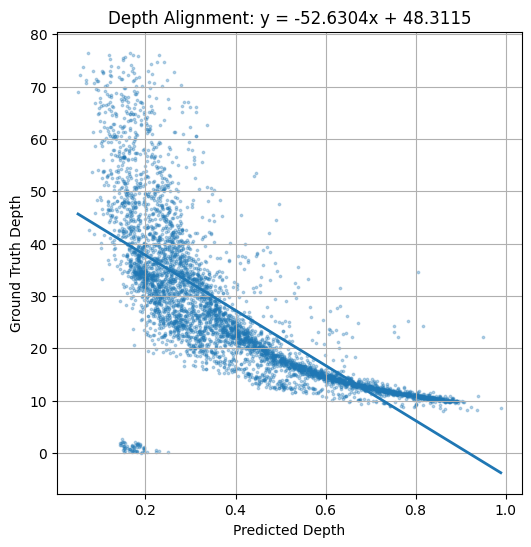

In [11]:
import matplotlib.pyplot as plt

sample_size = min(5000, len(x))
idx = np.random.choice(len(x), sample_size, replace=False)

x_sample = x[idx]
y_sample = y[idx]

x_line = np.linspace(x_sample.min(), x_sample.max(), 100)
y_line = m * x_line + c

plt.figure(figsize=(6, 6))
plt.scatter(x_sample, y_sample, s=3, alpha=0.3)
plt.plot(x_line, y_line, linewidth=2)
plt.xlabel("Predicted Depth")
plt.ylabel("Ground Truth Depth")
plt.title(f"Depth Alignment: y = {m:.4f}x + {c:.4f}")
plt.grid(True)
plt.show()

In [17]:
import numpy as np

def eigen_crop(depth_map):
    h, w = depth_map.shape
    crop_mask = np.zeros((h, w), dtype=bool)

    y1 = int(0.408 * h)
    y2 = int(0.992 * h)
    x1 = int(0.036 * w)
    x2 = int(0.964 * w)

    crop_mask[y1:y2, x1:x2] = True
    return crop_mask

# Load stacks
groundtruth_stack = np.load("data/groundtruth.npy")
model_stack = np.load("data/all_depth.npy")

print("GT shape:", groundtruth_stack.shape)
print("Model shape:", model_stack.shape)

# Apply Eigen crop masks
crop_masks = []
for frame in groundtruth_stack:
    crop_masks.append(eigen_crop(frame))

crop_masks = np.stack(crop_masks)

# Flatten
gt_flat = groundtruth_stack.flatten()
model_flat = model_stack.flatten()
mask_flat = crop_masks.flatten()

# Valid pixels
valid_mask = (
    mask_flat &
    np.isfinite(gt_flat) & (gt_flat > 0) &
    np.isfinite(model_flat) & (model_flat > 0)
)

gt_valid = gt_flat[valid_mask]
model_valid = model_flat[valid_mask]

print("valid cropped pixels:", len(gt_valid))

GT shape: (199, 192, 640)
Model shape: (199, 192, 640)
valid cropped pixels: 3202461


In [18]:
A = np.vstack([model_valid, np.ones_like(model_valid)]).T
m, c = np.linalg.lstsq(A, gt_valid, rcond=None)[0]

print("Linear fit:")
print("m =", m)
print("c =", c)
print(f"GT = {m:.6f} * Pred + {c:.6f}")

pred_aligned = m * model_stack + c

rmse_before = np.sqrt(np.mean((model_flat[valid_mask] - gt_flat[valid_mask]) ** 2))
rmse_after = np.sqrt(np.mean((pred_aligned.flatten()[valid_mask] - gt_flat[valid_mask]) ** 2))

print("RMSE before alignment:", rmse_before)
print("RMSE after alignment :", rmse_after)

Linear fit:
m = -55.05838
c = 49.541187
GT = -55.058380 * Pred + 49.541187
RMSE before alignment: 30.92557
RMSE after alignment : 9.646943
